In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize, LogStretch, SqrtStretch
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from photutils import DAOStarFinder
from astropy.stats import sigma_clipped_stats
from astropy.wcs.utils import proj_plane_pixel_scales

plt.style.use("science")

In [2]:
path = "../data/icl901010_drz.fits"
data = fits.open(path)

In [3]:
data.info()

Filename: ../data/icl901010_drz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     909   ()      
  1  SCI           1 ImageHDU        83   (1356, 1232)   float32   
  2  WHT           1 ImageHDU        45   (1356, 1232)   float32   
  3  CTX           1 ImageHDU        40   (1356, 1232)   int32   
  4  HDRTAB        1 BinTableHDU    559   9R x 275C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, K, 2A, 9A, 7A, 18A, D, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, K, D, 3A, D, D, D, D, K, K, 8A, 23A, 11A, 19A, 4A, D, D, K, K, D, D, D, D, 23A, D, D, D, D, K, K, D, 3A, 8A, L, D, D, D, 23A, 1A, D, D, D, D, D, D, 12A, 12A, 8A, 23A, D, D, 10A, 10A, D, D, D, 2A, 23A, 3A, 4A, 8A, 7A, D, K, D, 6A, 9A, D, D, D, 4A, 18A, 3A, K, 5A, D, D, D, 8A, D, 3A, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, L, 1A, 4A, D, 3A, 6A, D, D, D, D, D, 23A, D, D, D, D, D, 1A, K, K, K, K, 8A, 23A, K, K, 10A, 7A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D,

In [4]:
data["SCI"].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 1356                                                  
NAXIS2  =                 1232                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
INHERIT =                    T / inherit the primary header                     
EXTNAME = 'SCI     '           / extension name                                 
EXTVER  =                    1 / extension version number                       
ROOTNAME= 'icl901ezq                         ' / rootname of the observation set
EXPNAME = 'icl901ezq                ' / exposure identifier                     
BUNIT   = 'ELECTRONS/S'     

In [7]:
wcs = WCS(data["SCI"].header)


In [8]:
proj_plane_pixel_scales(wcs) * 3600

array([0.12825, 0.12825])

In [9]:
np.sqrt(data["SCI"].header["CD1_1"]**2 + data["SCI"].header["CD1_2"]**2) * 3600

0.12825000286102264

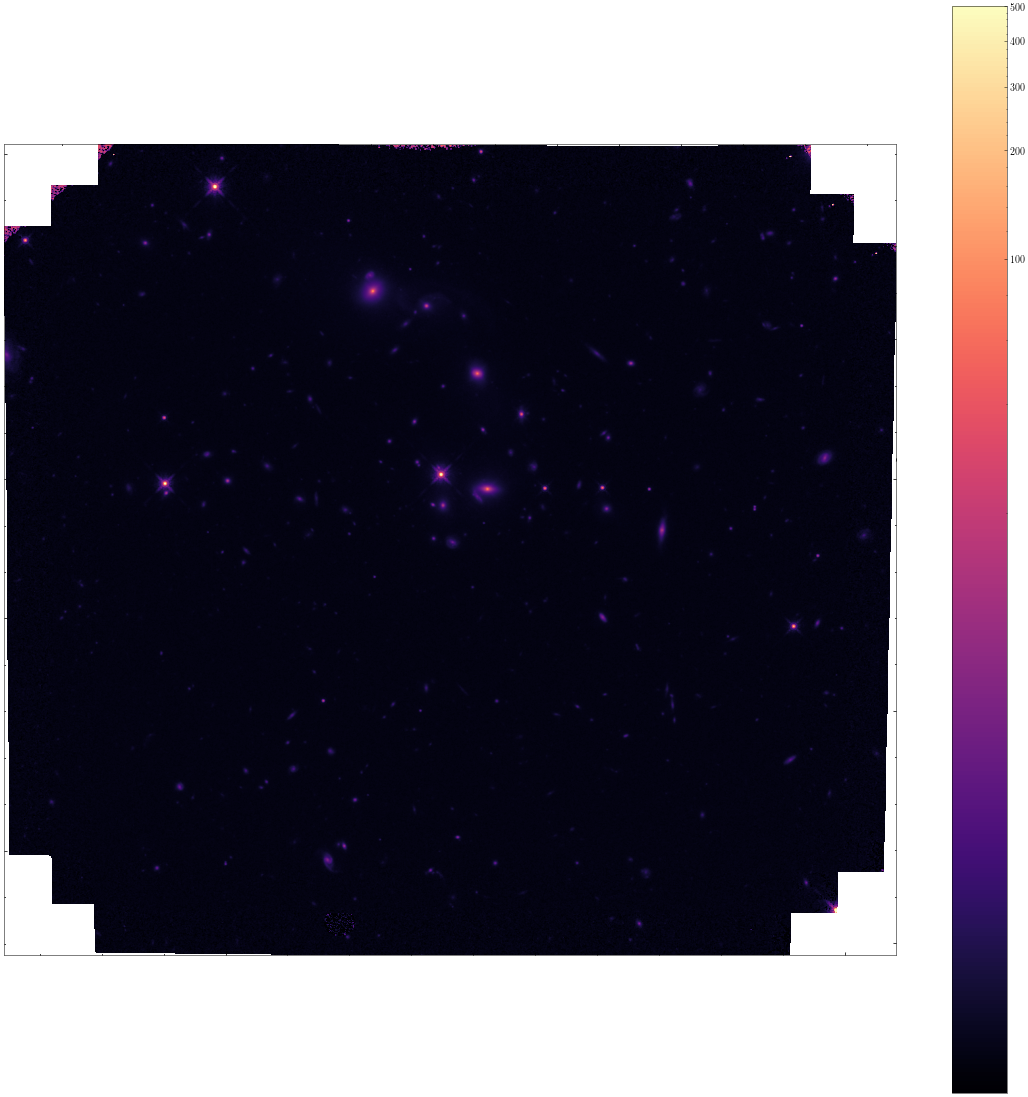

In [10]:

fig = plt.figure(figsize=(20, 20))
fig.add_subplot(projection=wcs)
plt.imshow(data["SCI"].data, cmap="magma", norm=ImageNormalize(vmax=500, vmin=0.5, stretch=LogStretch()))
plt.colorbar()

In [11]:
size = 40 * u.pixel
coord = SkyCoord("03:00:00.5687857104", "00:48:27.963948708", unit=(u.hourangle, u.deg))
cutout = Cutout2D(data["SCI"].data, coord, size, wcs=wcs)
# coords = SkyCoord("11:25:26.1194999280", "00:29:01.358157048", unit=(u.hourangle, u.deg))

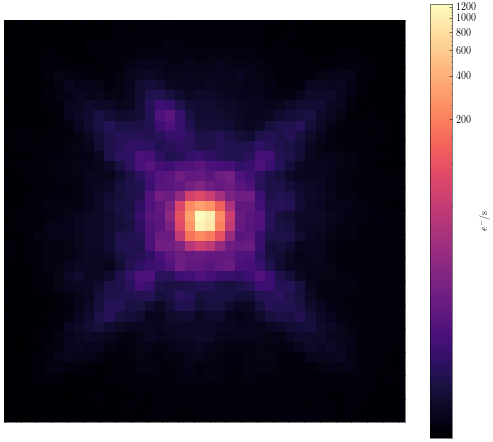

In [12]:
# wcs = WCS(data["SCI"].header)
fig = plt.figure(figsize=(9, 8))
fig.add_subplot(projection=cutout.wcs)
plt.imshow(cutout.data, cmap="magma", norm=ImageNormalize(stretch=LogStretch()))
plt.colorbar(label=r"$e^{-}$/s")
plt.ylabel("Declination")
plt.xlabel("Right ascension")

In [13]:
# fits.PrimaryHDU(cutout.data, header=cutout.wcs.to_header()).writeto("target1.fits")

# Find stars

In [14]:
wcs.world_to_pixel(coord)

(array(663.20542955), array(728.29406705))

In [15]:
mean, median, std = sigma_clipped_stats(data["SCI"].data,  sigma=200.0)
print(mean, median, std)
daofind = DAOStarFinder(fwhm=3.0, threshold=5.*std)
sources = daofind(data["SCI"].data)
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
len(positions)

0.6775459 0.63767946 1.42151


68

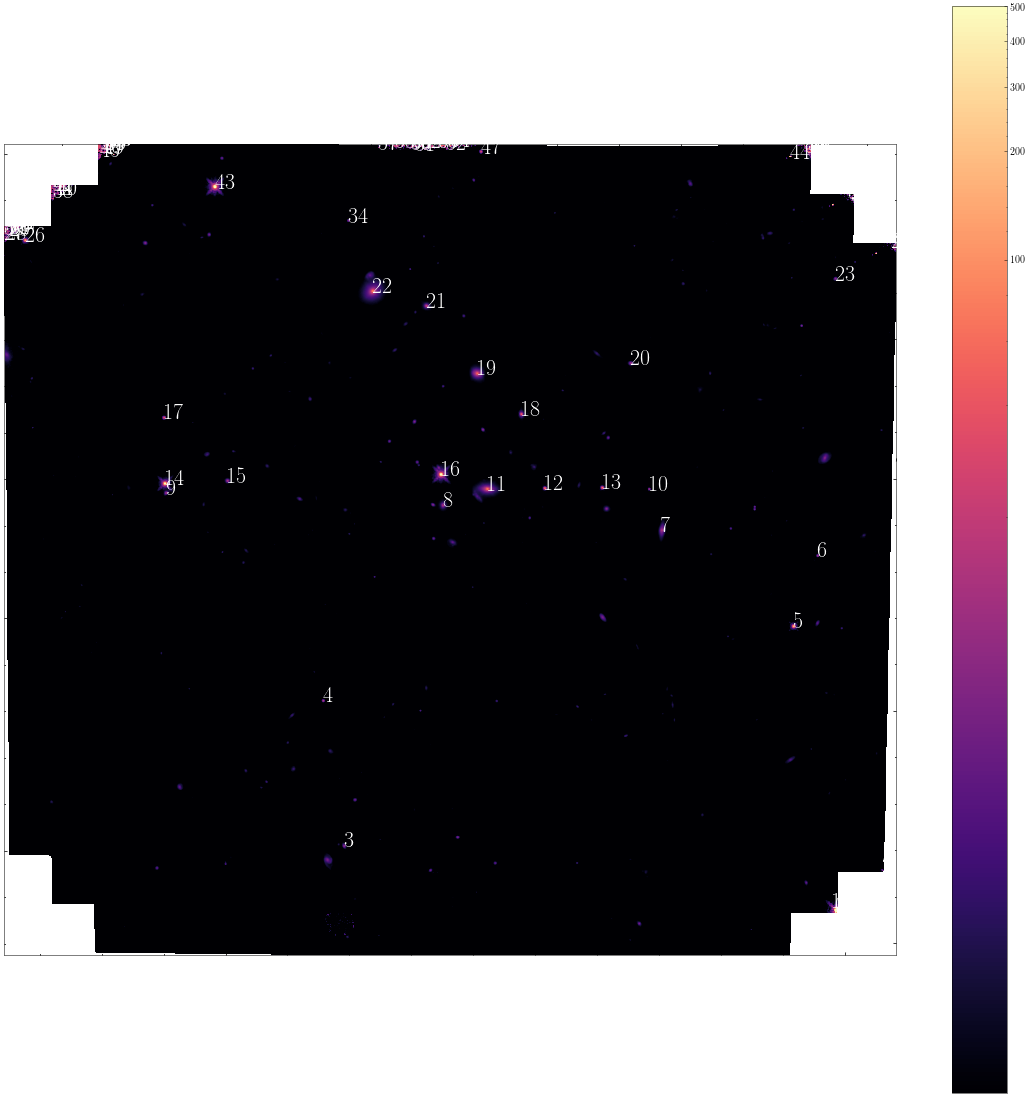

In [16]:
wcs = WCS(data["SCI"].header)

fig = plt.figure(figsize=(20, 20))
fig.add_subplot(projection=wcs)
plt.imshow(data["SCI"].data, cmap="magma", norm=ImageNormalize(vmax=500, vmin=1, stretch=LogStretch()))
plt.colorbar()

for i, pos in enumerate(positions):
    plt.annotate(f"{i}", xy=pos, fontsize=22, color="w")

In [17]:
psf_cutouts = []
for pos in positions[[43, 5]]:
    size = 40 * u.pixel
    coord = SkyCoord(wcs.pixel_to_world(pos[0], pos[1]), unit=u.deg)
    psf_cutouts.append(Cutout2D(data["SCI"].data, coord, size, wcs=wcs))
# coords = SkyCoord("11:25:26.1194999280", "00:29:01.358157048", unit=(u.hourangle, u.deg))

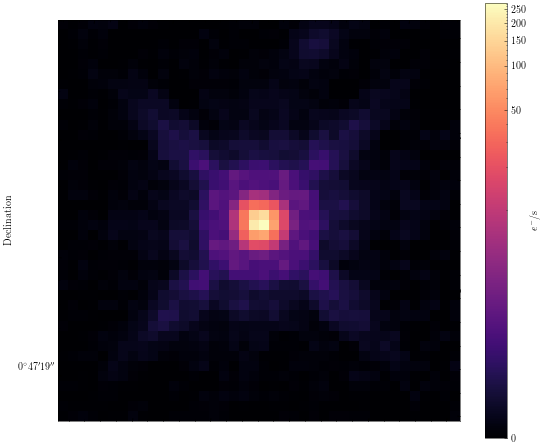

In [23]:
# wcs = WCS(data["SCI"].header)

i = 1
fig = plt.figure(figsize=(9, 8))
fig.add_subplot(projection=psf_cutouts[i].wcs)
plt.imshow(psf_cutouts[i].data - 0.64, cmap="magma", norm=ImageNormalize(stretch=LogStretch(), vmin=0))
# plt.imshow((psf_cutouts[i].data - 0.64) < 0)

plt.colorbar(label=r"$e^{-}$/s")
plt.ylabel("Declination")
plt.xlabel("Right ascension")

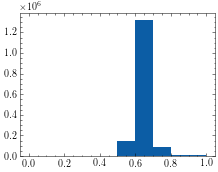

In [121]:
x = data["SCI"].data[data["SCI"].data < 1]
x[x < 0] = 0
plt.hist(x);

In [122]:
x.mean()

0.6401881

In [123]:
x.std()

0.05597879

In [108]:
# psf1 = psf_cutouts[1].data
# psf1[psf1 < 0] = 0
# psf1 /= psf1.sum()

# hdu = fits.PrimaryHDU(psf1, header=psf_cutouts[1].wcs.to_header())

# psf2 = psf_cutouts[0].data
# psf2[psf2 < 0] = 0
# psf2 /= psf2.sum()
# hdu2 = fits.ImageHDU(psf2, header=psf_cutouts[0].wcs.to_header())
# hdul = fits.HDUList([hdu, hdu2])
# hdul.writeto("psf_target1.fits")

# Estimate some statistics

In [ ]:
size = 40 * u.pixel
coord = SkyCoord("03:00:00.56878571", "00:48:27.963948708", unit=(u.hourangle, u.deg))
dark_cutout = Cutout2D(data["SCI"].data, coord, size, wcs=wcs)
# coords = SkyCoord("11:25:26.1194999280", "00:29:01.358157048", unit=(u.hourangle, u.deg))